# Lab 7: Rock-Paper-Scissors Image Classification

This lab focuses on building and training a convolutional neural network (CNN) to classify images from the Rock-Paper-Scissors dataset using PyTorch. The dataset consists of images of hand gestures representing rock, paper, and scissors, split into training and test sets. The objectives of this lab are to:

- Download and preprocess the dataset with appropriate transformations (including data augmentation for training).
- Define a custom CNN architecture (`RPSNet`) for image classification.
- Train the model with the Adam optimizer, cosine annealing learning rate scheduling, and cross-entropy loss.
- Evaluate model performance using accuracy and a confusion matrix.
- Visualize sample images and predictions to assess the model's performance qualitatively.

In [ ]:
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import numpy as np

### Download and Extract Rock-Paper-Scissors Dataset

Function `download_rps` to download and extract the Rock-Paper-Scissors dataset.

In [ ]:
import requests
import zipfile
import os
import errno

def download_rps(localfolder=''):
    filenames = ['rps.zip', 'rps-test-set.zip']
    for filename in filenames:
        try:
            os.mkdir(f'{localfolder}{filename[:-4]}')

            localfile = f'{localfolder}{filename}'
            # url = 'https://storage.googleapis.com/laurencemoroney-blog.appspot.com/{}'
            # Updated from TFDS URL at
            # https://github.com/tensorflow/datasets/blob/master/tensorflow_datasets/datasets/rock_paper_scissors/rock_paper_scissors_dataset_builder.py
            url = 'https://storage.googleapis.com/download.tensorflow.org/data/{}'
            r = requests.get(url.format(filename), allow_redirects=True)
            open(localfile, 'wb').write(r.content)
            with zipfile.ZipFile(localfile, 'r') as zip_ref:
                zip_ref.extractall(localfolder)
        except OSError as e:
            if e.errno != errno.EEXIST:
                raise
            else:
                print(f'{filename[:-4]} folder already exists!')

In [ ]:
download_rps()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


### Define Dataset Directories and Verify Existence

Set up paths for the training (`rps`) and test (`rps-test-set`) directories using the `Path` class.

In [ ]:

train_dir = Path("rps")
test_dir  = Path("rps-test-set")

assert train_dir.exists(), "Expected folder 'rps/' not found. Run download_rps() first."
assert test_dir.exists(),  "Expected folder 'rps-test-set/' not found. Run download_rps() first."
print("Classes:", sorted([d.name for d in train_dir.iterdir() if d.is_dir()]))


Classes: ['paper', 'rock', 'scissors']


### Image Transformations and Dataset Loading

Define image preprocessing and augmentation pipelines for the Rock-Paper-Scissors dataset using PyTorch's `transforms`.

In [ ]:
# Define a fixed image size to resize all input images to
IMG_SIZE = 128

# Define transformations for training data (with augmentations)
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),           # Resize images to 128x128
    transforms.RandomHorizontalFlip(p=0.5),            # Randomly flip images horizontally (50% chance)
    transforms.RandomRotation(degrees=10),             # Randomly rotate images within ±10 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Slightly change brightness and contrast
    transforms.ToTensor(),                             # Convert image to PyTorch tensor (HWC → CHW, normalized to [0,1])
    transforms.Normalize(mean=(0.5, 0.5, 0.5),         # Normalize with mean and std for each channel
                         std=(0.5, 0.5, 0.5)),         # (scales pixel values to roughly [-1, 1])
])

# Define transformations for test/validation data (without augmentations)
test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),           # Resize images to 128x128
    transforms.ToTensor(),                             # Convert to tensor
    transforms.Normalize(mean=(0.5, 0.5, 0.5),         # Apply same normalization as training
                         std=(0.5, 0.5, 0.5)),
])

# Load training dataset from directory, applying training transforms
train_ds = datasets.ImageFolder(root=str(train_dir), transform=train_tfms)

# Load testing dataset from directory, applying test transforms
test_ds  = datasets.ImageFolder(root=str(test_dir),  transform=test_tfms)

# Get number of classes from dataset (ImageFolder infers classes from subfolder names)
num_classes = len(train_ds.classes)

# Print class names detected in the dataset
print("Classes:", train_ds.classes)


Classes: ['paper', 'rock', 'scissors']


### Visualize Sample Images from Training Dataset

Define a helper function `show_image` to unnormalize a PyTorch tensor image (reversing the [-1, 1] normalization to [0, 1] range)

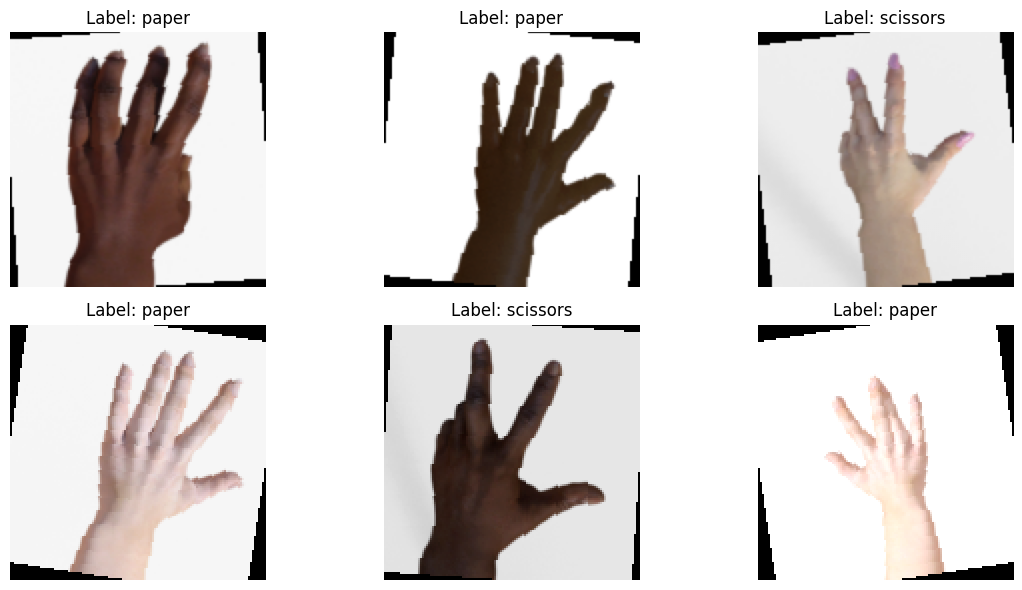

In [ ]:
import matplotlib.pyplot as plt

# Function to unnormalize and display an image
def show_image(img, label, classes):
    # Undo normalization (from [-1, 1] back to [0, 1])
    img = img * 0.5 + 0.5
    img = img.permute(1, 2, 0).numpy()  # Convert from (C, H, W) → (H, W, C)

    plt.imshow(img)
    plt.title(f"Label: {classes[label]}")
    plt.axis("off")

# Create a DataLoader to fetch a batch of images
from torch.utils.data import DataLoader
train_loader = DataLoader(train_ds, batch_size=6, shuffle=True)

# Get one batch of images and labels
images, labels = next(iter(train_loader))

# Plot the images
plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)  # Arrange in a 2x3 grid
    show_image(images[i], labels[i].item(), train_ds.classes)

plt.tight_layout()
plt.show()


### Create DataLoaders for Training and Testing

Set up `DataLoader` objects for the training and test datasets.

In [ ]:
BATCH_SIZE = 64
NUM_WORKERS = 2  # set to 0 on Windows if you see issues

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

### Define Convolutional Neural Network for Rock-Paper-Scissors Classification

Define a convolutional neural network (CNN) for the Rock-Paper-Scissors dataset.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)

class RPSNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),               # -> [B,32,128,128]
            ConvBlock(32, 32),
            nn.MaxPool2d(2),                # -> [B,32,64,64]

            ConvBlock(32, 64),
            ConvBlock(64, 64),
            nn.MaxPool2d(2),                # -> [B,64,32,32]

            ConvBlock(64, 128),
            ConvBlock(128, 128),
            nn.MaxPool2d(2),                # -> [B,128,16,16]

            ConvBlock(128, 256),
            nn.MaxPool2d(2),                # -> [B,256,8,8]
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),        # -> [B,256,1,1]
            nn.Flatten(),                   # -> [B,256]
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)     # logits
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = RPSNet(num_classes=num_classes).to(device)
sum(p.numel() for p in model.parameters())/1e6
print(model)

RPSNet(
  (features): Sequential(
    (0): ConvBlock(
      (net): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (net): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): ConvBlock(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (4): ConvBlock(
      (net): Sequential(
        (0): 

### Training Configuration for RPSNet

Configure the training process for the `RPSNet` model.

In [ ]:
EPOCHS = 12
lr = 3e-4
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
# Optional scheduler:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

### Training and Evaluation Function for One Epoch

Define a function `run_epoch` to handle both training and evaluation of the `RPSNet` model for a single epoch.

In [ ]:
def run_epoch(model, loader, train=True):
    model.train(train)
    total, correct, total_loss = 0, 0, 0.0

    if train:
        torch.set_grad_enabled(True)
    else:
        torch.set_grad_enabled(False)

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


### Training Loop with Model Checkpointing

This code block implements the training loop for the `RPSNet` model over the specified number of epochs.

In [ ]:
best_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    val_loss,   val_acc   = run_epoch(model, test_loader,  train=False)

    if scheduler is not None:
        scheduler.step()

    if val_acc > best_acc:
        best_acc = val_acc
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} acc={train_acc:.3f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.3f}")

# Save best (optional)
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    torch.save(model.state_dict(), "rps_cnn_best.pt")
    print(f"Best val acc: {best_acc:.3f} — model saved to rps_cnn_best.pt")


Epoch 01/12 | train_loss=0.6710 acc=0.753 | val_loss=1.6595 acc=0.333
Epoch 02/12 | train_loss=0.2332 acc=0.968 | val_loss=0.8572 acc=0.661
Epoch 03/12 | train_loss=0.1135 acc=0.988 | val_loss=1.5753 acc=0.336
Epoch 04/12 | train_loss=0.0765 acc=0.993 | val_loss=0.4921 acc=0.758
Epoch 05/12 | train_loss=0.0435 acc=0.999 | val_loss=0.4648 acc=0.758
Epoch 06/12 | train_loss=0.0344 acc=0.998 | val_loss=0.5593 acc=0.739
Epoch 07/12 | train_loss=0.0304 acc=0.999 | val_loss=0.3450 acc=0.871
Epoch 08/12 | train_loss=0.0231 acc=1.000 | val_loss=0.4000 acc=0.858
Epoch 09/12 | train_loss=0.0192 acc=1.000 | val_loss=0.5862 acc=0.720
Epoch 10/12 | train_loss=0.0191 acc=1.000 | val_loss=0.5872 acc=0.720
Epoch 11/12 | train_loss=0.0153 acc=1.000 | val_loss=0.5904 acc=0.723
Epoch 12/12 | train_loss=0.0168 acc=1.000 | val_loss=0.6492 acc=0.720
Best val acc: 0.871 — model saved to rps_cnn_best.pt


### Compute and Display Confusion Matrix

This code block defines a function `confusion_matrix` to compute a confusion matrix for the `RPSNet` model on the test dataset.

In [ ]:
@torch.no_grad()
def confusion_matrix(model, loader, num_classes):
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    model.eval()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(dim=1)
        for t, p in zip(y.view(-1), preds.view(-1)):
            cm[t.long(), p.long()] += 1
    return cm.cpu().numpy()

cm = confusion_matrix(model, test_loader, num_classes)
print("Confusion matrix (rows=true, cols=pred):\n", cm)
print("Class order:", train_ds.classes)


Confusion matrix (rows=true, cols=pred):
 [[ 93  28   3]
 [  0 107  17]
 [  0   0 124]]
Class order: ['paper', 'rock', 'scissors']


### Visualize Random Predictions from Test Dataset

This code block defines a function `show_predictions_random` to display predictions for a random subset of images from the test dataset.

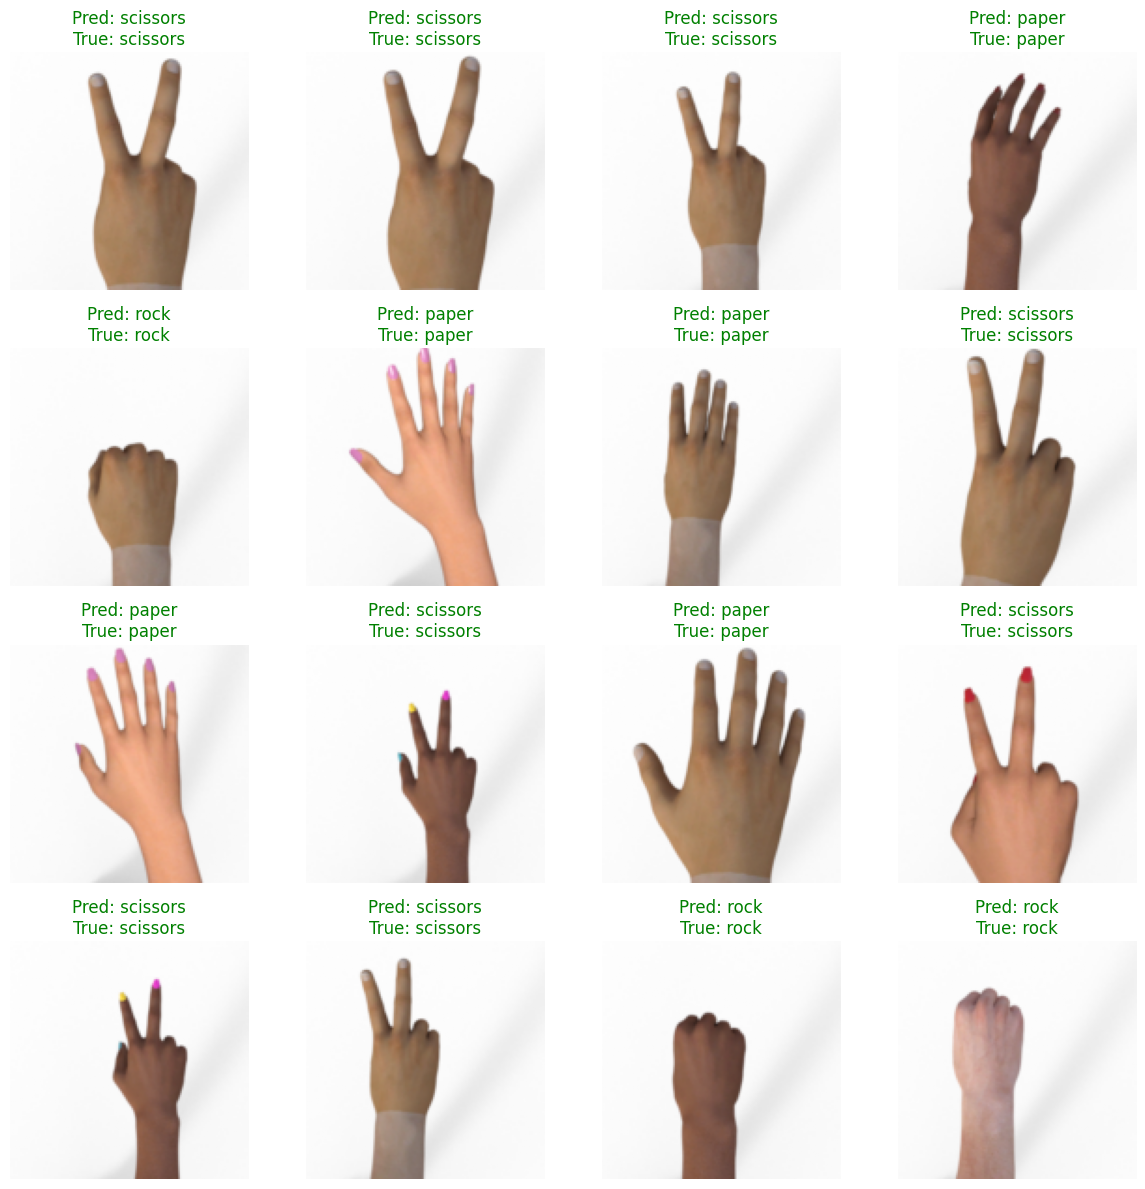

In [ ]:
import random

@torch.no_grad()
def show_predictions_random(model, dataset, classes, max_images=16):
    model.eval()
    indices = random.sample(range(len(dataset)), max_images)
    x_batch, y_batch = zip(*[dataset[i] for i in indices])

    x = torch.stack(x_batch).to(device)
    y = torch.tensor(y_batch).to(device)

    preds = model(x).argmax(dim=1).cpu()
    x_disp = (x.cpu() * 0.5 + 0.5).clamp(0,1)

    rows = int(np.ceil(max_images/4))
    fig, axes = plt.subplots(rows, 4, figsize=(12, 3*rows))
    for i, ax in enumerate(axes.flat):
        if i < max_images:
            img = np.transpose(x_disp[i].numpy(), (1,2,0))
            true_label = classes[y[i]]
            pred_label = classes[preds[i]]
            color = "green" if true_label == pred_label else "red"
            ax.imshow(img)
            ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
            ax.axis("off")
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.show()

# Usage:
show_predictions_random(model, test_ds, train_ds.classes, max_images=16)


# Lab 7: Student Exercises

To reinforce your understanding of the Rock-Paper-Scissors image classification task and deepen your skills in model evaluation and visualization, complete the following exercises.
These tasks extend the concepts covered in this lab and draw inspiration from techniques used in Lab 6.

## 1. Visualize the Confusion Matrix Using a Plot
Using the confusion matrix computed in the lab, create a visualization similar to the one used in Lab 6.
## 2. Log Training and Validation Metrics in TensorBoard
Extend the training loop to log the training and validation loss and accuracy metrics to TensorBoard for visualization. Use the `torch.utils.tensorboard` module to:
- Create a `SummaryWriter` to write logs to a directory (e.g., `runs/rps_experiment`).
- Log the training and validation loss and accuracy after each epoch.
- After training, launch TensorBoard to view the loss and accuracy curves over epochs.